In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout
from scikeras.wrappers import KerasClassifier # The bridge between Keras and Scikit-Learn

# 1. Load the pre-cleaned data
df_cleaned = pd.read_csv('../data/nasa_cleaned.csv')

# 2. Split into Features (X) and Target (y)
X = df_cleaned.drop('Hazardous', axis=1)
y = df_cleaned['Hazardous']

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Scale the Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data loaded, split, and scaled. Ready for Deep Learning!")

Data loaded, split, and scaled. Ready for Deep Learning!


In [5]:
# --- THE KERAS MODEL ARCHITECTURE ---

def create_model(hidden_layers=1, neurons=32, dropout_rate=0.2):
    # Initialize the constructor
    model = Sequential()
    
    # Input layer & First hidden layer
    # input_shape dynamically grabs the number of columns (39 features)
    model.add(Dense(neurons, input_shape=(X_train_scaled.shape[1],), activation='relu'))
    model.add(Dropout(dropout_rate))
    
    # Add additional hidden layers if requested by Grid Search
    for _ in range(hidden_layers - 1):
        model.add(Dense(neurons, activation='relu'))
        model.add(Dropout(dropout_rate))
        
    # Output layer (1 neuron with Sigmoid for binary classification: 0 or 1)
    model.add(Dense(1, activation='sigmoid'))
    
    # Compile the model
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Wrap the Keras function inside SciKeras so GridSearch can read it
from scikeras.wrappers import KerasClassifier
ann_estimator = KerasClassifier(model=create_model, verbose=0)
print("ANN Architecture defined and wrapped!")

ANN Architecture defined and wrapped!


In [6]:
# --- ANN HYPERPARAMETER TUNING ---

# Define the network shapes we want to test
# Keep this relatively small at first, or it will take hours to run!
param_grid = {
    'model__hidden_layers': [1, 2],       # Test a shallow vs deeper network
    'model__neurons': [16, 32],           # Test narrow vs wide layers
    'model__dropout_rate': [0.2, 0.4],    # Test low vs high dropout
    'batch_size': [32, 64],               # How many rows it learns before updating weights
    'epochs': [20, 50]                    # How many times it reads the whole dataset
}

print("Starting Deep Learning Grid Search... grab a coffee.")

# Set up the Grid Search (cv=3 to save time, scoring for recall like the SVM)
grid_search = GridSearchCV(estimator=ann_estimator, param_grid=param_grid, cv=3, scoring='recall', n_jobs=-1, verbose=1)

# Run the training
grid_search.fit(X_train_scaled, y_train)

# Extract the best model
best_ann = grid_search.best_estimator_

print(f"\nGrid Search Complete!")
print(f"Best Network Architecture: {grid_search.best_params_}")

Starting Deep Learning Grid Search... grab a coffee.
Fitting 3 folds for each of 32 candidates, totalling 96 fits


c:\Users\Edwar\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Grid Search Complete!
Best Network Architecture: {'batch_size': 32, 'epochs': 50, 'model__dropout_rate': 0.2, 'model__hidden_layers': 2, 'model__neurons': 16}


--- ANN Classification Report ---
              precision    recall  f1-score   support

       False       0.99      1.00      0.99       787
        True       0.99      0.95      0.97       151

    accuracy                           0.99       938
   macro avg       0.99      0.97      0.98       938
weighted avg       0.99      0.99      0.99       938



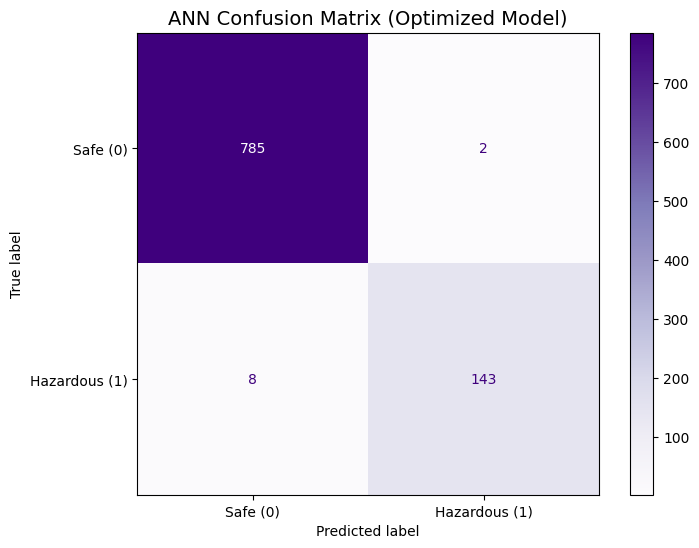

In [7]:
# --- EVALUATION & VISUALS ---

# Make predictions on the 20% holdout test set
y_pred = best_ann.predict(X_test_scaled)

# 1. Print the text report
print("--- ANN Classification Report ---")
print(classification_report(y_test, y_pred))

# 2. Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe (0)', 'Hazardous (1)'])

# Using a different color map (Purples) to easily distinguish from the SVM
disp.plot(cmap='Purples', values_format='d', ax=plt.gca())

plt.title('ANN Confusion Matrix (Optimized Model)', fontsize=14)
plt.show()